<a href="https://colab.research.google.com/github/QasimNiazi86/GAN/blob/main/Tutorial16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda
Starting GAN Training...
Epoch [1/50] | D Loss: 0.3758 | G Loss: 5.1038
Epoch [2/50] | D Loss: 1.2056 | G Loss: 1.8973
Epoch [3/50] | D Loss: 0.5068 | G Loss: 2.5075
Epoch [4/50] | D Loss: 0.1628 | G Loss: 2.7962
Epoch [5/50] | D Loss: 0.7490 | G Loss: 2.7944
Epoch [6/50] | D Loss: 0.8790 | G Loss: 2.0473
Epoch [7/50] | D Loss: 0.4295 | G Loss: 3.4044
Epoch [8/50] | D Loss: 0.3736 | G Loss: 3.4759
Epoch [9/50] | D Loss: 0.0366 | G Loss: 5.0740
Epoch [10/50] | D Loss: 0.2922 | G Loss: 4.4303


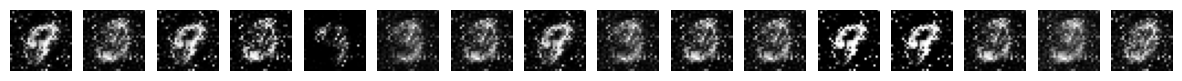

Epoch [11/50] | D Loss: 0.3479 | G Loss: 4.1939
Epoch [12/50] | D Loss: 0.5066 | G Loss: 2.8976
Epoch [13/50] | D Loss: 0.2573 | G Loss: 4.3486
Epoch [14/50] | D Loss: 0.4169 | G Loss: 5.3012
Epoch [15/50] | D Loss: 0.3864 | G Loss: 4.6443
Epoch [16/50] | D Loss: 0.1563 | G Loss: 6.0795
Epoch [17/50] | D Loss: 0.0923 | G Loss: 4.4727
Epoch [18/50] | D Loss: 0.2694 | G Loss: 3.5699
Epoch [19/50] | D Loss: 0.5266 | G Loss: 4.1217
Epoch [20/50] | D Loss: 0.1575 | G Loss: 4.9258


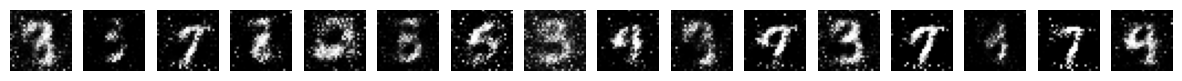

Epoch [21/50] | D Loss: 0.2496 | G Loss: 3.8065
Epoch [22/50] | D Loss: 0.3720 | G Loss: 4.4040
Epoch [23/50] | D Loss: 0.6401 | G Loss: 3.2874
Epoch [24/50] | D Loss: 1.0040 | G Loss: 3.7608
Epoch [25/50] | D Loss: 0.6666 | G Loss: 2.8559
Epoch [26/50] | D Loss: 0.3270 | G Loss: 3.3356
Epoch [27/50] | D Loss: 0.5343 | G Loss: 3.0893
Epoch [28/50] | D Loss: 0.3524 | G Loss: 2.5109
Epoch [29/50] | D Loss: 0.4984 | G Loss: 3.8296
Epoch [30/50] | D Loss: 0.7742 | G Loss: 1.4094


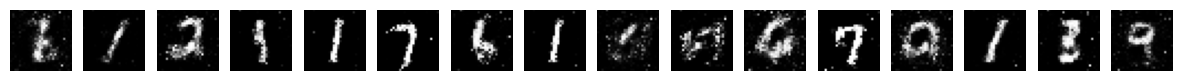

Epoch [31/50] | D Loss: 0.6393 | G Loss: 2.4325
Epoch [32/50] | D Loss: 0.6833 | G Loss: 1.9809
Epoch [33/50] | D Loss: 0.7649 | G Loss: 2.5884
Epoch [34/50] | D Loss: 0.4365 | G Loss: 2.1077
Epoch [35/50] | D Loss: 0.3502 | G Loss: 2.6612
Epoch [36/50] | D Loss: 0.9043 | G Loss: 1.8739
Epoch [37/50] | D Loss: 0.7614 | G Loss: 2.0069
Epoch [38/50] | D Loss: 0.5178 | G Loss: 2.6422
Epoch [39/50] | D Loss: 0.7671 | G Loss: 1.7389
Epoch [40/50] | D Loss: 0.7655 | G Loss: 1.8374


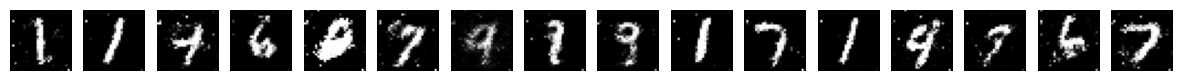

Epoch [41/50] | D Loss: 0.6978 | G Loss: 2.1722
Epoch [42/50] | D Loss: 0.7018 | G Loss: 1.8868
Epoch [43/50] | D Loss: 0.8642 | G Loss: 1.6363
Epoch [44/50] | D Loss: 0.7378 | G Loss: 1.8486
Epoch [45/50] | D Loss: 0.9378 | G Loss: 2.2857
Epoch [46/50] | D Loss: 0.7848 | G Loss: 1.8472
Epoch [47/50] | D Loss: 1.0942 | G Loss: 1.7979
Epoch [48/50] | D Loss: 0.4647 | G Loss: 1.7455
Epoch [49/50] | D Loss: 0.7110 | G Loss: 1.8430
Epoch [50/50] | D Loss: 0.7699 | G Loss: 1.9940


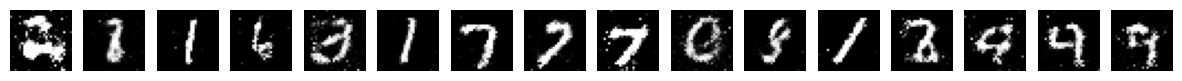


Final Generated Images:


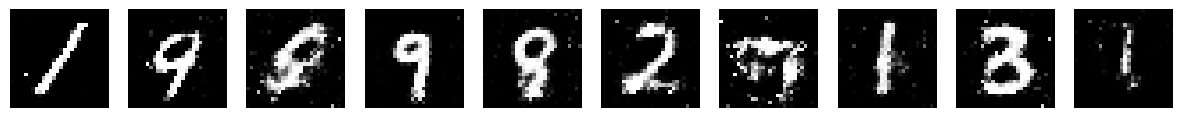

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Configuration & Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

latent_dim = 100 # Size of the random noise vector
batch_size = 64
epochs = 50

# 2. Load and Prepare MNIST Dataset
# Normalize to range [-1, 1] which works best with the Generator's Tanh output
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Fixed from source (was 8.5) to standard 0.5
])

train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 3. Define the Generator
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh() # Output in range [-1, 1]
        )

    def forward(self, z):
        return self.model(z).view(z.size(0), 1, 28, 28)

generator = Generator(latent_dim).to(device)

# 4. Define the Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid() # Output probability
        )

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten the image
        return self.model(x)

discriminator = Discriminator().to(device)

# 5. Define Loss Function and Optimizers
criterion = nn.BCELoss()
lr = 0.0002

generator_optimizer = optim.Adam(generator.parameters(), lr=lr)
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=lr)

# Visualization helper function
def visualize_images(generator, latent_dim, num_images=16):
    generator.eval()
    noise = torch.randn(num_images, latent_dim).to(device)
    with torch.no_grad():
        generated_images = generator(noise).cpu()

    # Plot images
    fig, axes = plt.subplots(1, num_images, figsize=(15, 2))
    for i in range(num_images):
        axes[i].imshow(generated_images[i].squeeze(), cmap="gray")
        axes[i].axis("off")
    plt.show()
    generator.train()

# 6. Training Loop
def train_gan(generator, discriminator, train_loader, epochs, latent_dim):
    print("Starting GAN Training...")
    for epoch in range(epochs):
        for i, (real_images, _) in enumerate(train_loader):
            current_batch_size = real_images.size(0)
            real_images = real_images.to(device)

            # Labels: Real = 1, Fake = 0
            real_labels = torch.ones(current_batch_size, 1).to(device)
            fake_labels = torch.zeros(current_batch_size, 1).to(device)

            # ---------------------
            # Train Discriminator
            # ---------------------
            discriminator_optimizer.zero_grad()

            # Loss for real images
            real_outputs = discriminator(real_images)
            real_loss = criterion(real_outputs, real_labels)

            # Generate fake images
            noise = torch.randn(current_batch_size, latent_dim).to(device)
            fake_images = generator(noise)

            # Loss for fake images (detach so we don't backprop into generator yet)
            fake_outputs = discriminator(fake_images.detach())
            fake_loss = criterion(fake_outputs, fake_labels)

            # Total Discriminator loss
            d_loss = real_loss + fake_loss
            d_loss.backward()
            discriminator_optimizer.step()

            # ---------------------
            # Train Generator
            # ---------------------
            generator_optimizer.zero_grad()

            # Re-evaluate fake images for generator loss
            fake_outputs = discriminator(fake_images)
            # We want to fool the discriminator, so target label is 'real' (1)
            g_loss = criterion(fake_outputs, real_labels)
            g_loss.backward()
            generator_optimizer.step()

        # Print losses for the current epoch
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

        # Visualize generated images every 10 epochs
        if (epoch + 1) % 10 == 0:
            visualize_images(generator, latent_dim)

# 7. Run the Training
train_gan(generator, discriminator, train_loader, epochs, latent_dim)

# 8. Generate Final Images
print("\nFinal Generated Images:")
visualize_images(generator, latent_dim, num_images=10)